In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 10)
pd.options.display.float_format = '{:.2f}'.format
sns.set()

In [80]:
#1. Get data

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')
df_train.head()

train = df_train.to_numpy()
test = df_test.to_numpy()
train

array([[2, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       ...,
       [8, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [81]:
ms = train.shape[0]
ns = train.shape[1]
mt, nt = test.shape

X_train = train[:,1:ns]
X_train = (X_train.T)/255
y_train = train[:,0]
X_test = test[:,1:nt]
X_test = (X_test.T)/255
y_test = test[:,0]
X_train

# Network architecture
neur1 = 128
neur2 = 64
neur3 = 10  # Output layer

m = X_train.shape[1]   #number of training examples
n = X_train.shape[0]   #number of features (pixels)

In [82]:
# Dataset Distribution

In [83]:
def xavierInitialization():
    W1 = np.random.randn(neur1, n) * np.sqrt(2. / (n + neur1))
    b1 = np.zeros((neur1, 1))
    W2 = np.random.randn(neur2, neur1) * np.sqrt(2. / (neur1 + neur2))
    b2 = np.zeros((neur2, 1))
    W3 = np.random.randn(neur3, neur2) * np.sqrt(2. / (neur2 + neur3))
    b3 = np.zeros((neur3, 1))
    
    return W1, b1, W2, b2, W3, b3

In [84]:
#Activation Functions
def ReLU(z):
    return np.maximum(z,0)

def dReLU(z):
    return z>0

def LeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, vector, alpha * vector)

def dLeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, 1, alpha)

def softmax(vector):
    vector = np.array(vector)
    e_x = np.exp(vector - np.max(vector, axis=0, keepdims=True))
    return e_x / e_x.sum(axis=0, keepdims=True)

def dSoftmax(vector):
    vector = np.array(vector)
    s = softmax(vector)
    return np.diagflat(s) - np.outer(s, s)

def tanh(vector):
    vector = np.array(vector)
    return np.tanh(vector)

def dTanh(vector):
    vector = np.array(vector)
    return 1 - np.tanh(vector)**2

def sigmoid(vector):
    vector = np.array(vector)
    return 1 / (1 + np.exp(-vector))

def dSigmoid(vector):
    vector = np.array(vector)
    s = sigmoid(vector)
    return s * (1 - s)


In [85]:
# One-Hot Encoding
def one_hot(Y):
    init_one = np.zeros((neur3, m))
    init_one[Y[np.arange(m)], np.arange(m)] = 1
    return init_one

In [86]:
# Forward Propagation
def forward_pass(W1, b1, W2, b2, W3, b3, X):
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = sigmoid(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

In [87]:
# Backward Propagation
def crossentropy_backpropagation(Z1, A1, Z2, A2, Z3, A3, W3, W2, X, y):
    Y_one_hot = one_hot(y)
    
    dL_dZ3 = A3 - Y_one_hot
    dL_db3 = (1 / m) * (np.sum(dL_dZ3, axis=1).reshape(neur3, 1))
    dL_dW3 = (1 / m) * (dL_dZ3.dot(A2.T))
    
    dL_dZ2 = W3.T.dot(dL_dZ3) * dSigmoid(Z2)
    dL_db2 = (1 / m) * (np.sum(dL_dZ2, axis=1).reshape(neur2, 1))
    dL_dW2 = (1 / m) * (dL_dZ2.dot(A1.T))
    
    dL_dZ1 = W2.T.dot(dL_dZ2) * dSigmoid(Z1)
    dL_db1 = (1 / m) * (np.sum(dL_dZ1, axis=1).reshape(neur1, 1))
    dL_dW1 = (1 / m) * (dL_dZ1.dot(X.T))
    
    return dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1

In [88]:
# Update Parameters
def update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha):
    W1 -= alpha * dL_dW1
    b1 -= alpha * dL_db1
    W2 -= alpha * dL_dW2
    b2 -= alpha * dL_db2
    W3 -= alpha * dL_dW3
    b3 -= alpha * dL_db3
    return W1, b1, W2, b2, W3, b3

In [89]:
# Predictions
def get_predictions(A3):
    return np.argmax(A3, 0)


In [90]:
#Accuracy
def get_accuracy(predictions,y):
    print(predictions,y)
    return np.sum(predictions == y)/y.size

In [91]:
def compute_loss(A3, Y):
    return -np.sum(Y * np.log(A3)) / m

In [92]:
# Gradient Descent
def gradient_descent(X, y, epochs, alpha):
    W1, b1, W2, b2, W3, b3 = xavierInitialization()

    accuracy_scores = []
    loss_list = []
    
    for i in range(epochs):
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X)
        
        loss = compute_loss(A3, one_hot(y))
        loss_list.append(loss)
        
        dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1 = crossentropy_backpropagation(Z1, A1, Z2, A2, Z3, A3, W3, W2, X, y)
        
        W1, b1, W2, b2, W3, b3 = update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha)

        accuracy = get_accuracy(get_predictions(A3), y)
        accuracy_scores.append(accuracy)
        
        if i % 5 == 0:
            print("Iteration: ", i)
            print("Loss: ", loss)
            print("Accuracy: ", accuracy)
            print('*' * 20)
    
    return W1, b1, W2, b2, W3, b3, Z3, A3, accuracy_scores, loss_list


In [93]:
W1, b1, W2, b2, W3, b3, Z3, A3, accuracy, loss = gradient_descent(X_train, y_train, 501, 0.1)

[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
Iteration:  0
Loss:  2.6961531803718857
Accuracy:  0.1
********************
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
Iteration:  5
Loss:  2.299846610997669
Accuracy:  0.10006666666666666
********************
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 9 5] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 9 5] [2 9 6 ... 8 8 7]
[5 5 3 ... 3 9 5] [2 9 6 ... 8 8 7]
[4 5 3 ... 3 9 5] [2 9 6 ... 8 8 7]
Iteration:  10
Loss:  2.26706527256444
Accuracy:  0.18791666666666668
********************
[4 5 4 ... 3 9 5] [2 9 6 ... 8 8 7]
[4 5 4 ... 3 9 5] [2 9 6 ... 8 8 7]
[4 7 4 ... 3 9 5] [2 9 6 ... 8 8 7]
[4 7 4 ... 3 9 5] [2 9 6 ... 8 8 7]
[4 7 4 ... 3 9 7] [2 9 6 ... 8 8 7]
Iteration:  15
Loss:  2.2517814746443126
Accuracy:  0.27581666666666665
********************
[4 7 4 ... 3 9 7] [2 9 6 ... 8 8 7]
[4 7 4 ... 3 9 7] [2 9 6 ... 8 8 7]
[

In [94]:
# Validation
Z1, A1, Z2, A2, Z3, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X_test)
print("Test Accuracy: ", get_accuracy(get_predictions(A3), y_test))


[0 1 2 ... 8 8 4] [0 1 2 ... 8 8 1]
Test Accuracy:  0.7047


In [95]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_test[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2, W3, b3)
    label = y_test[index]
    print('Prediction: ', prediction)
    print('Label: ', label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [9]
Label:  5


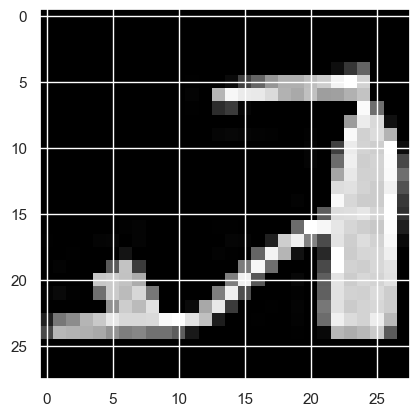

In [96]:
test_prediction(9800, W1, b1, W2, b2, W3, b3)

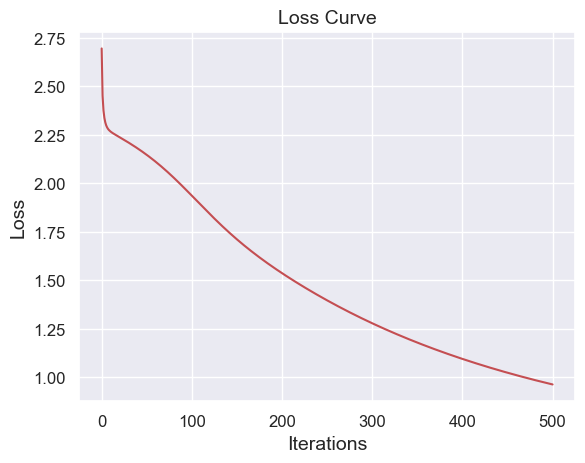

In [97]:
plt.plot(loss, linestyle='-', color='r')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

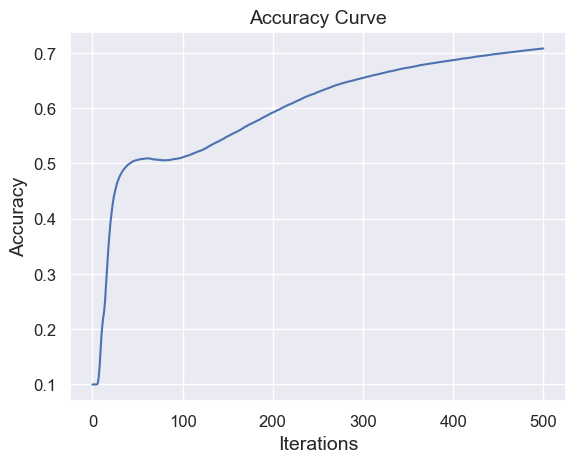

In [98]:
plt.plot(accuracy, linestyle='-', color='b')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

In [99]:
predictions = get_predictions(A3)
predictions[67]

9

In [100]:
confusion = confusion_matrix(y_test, predictions)
print(confusion)

[[774   7  18 108   4   8  63   1  17   0]
 [ 14 923  15  34   8   1   5   0   0   0]
 [ 13   2 562   6 256   1 141   0  19   0]
 [ 71  61   4 809  15   1  37   0   2   0]
 [ 13  19 280  86 548   2  44   0   8   0]
 [  0   0   1   5   0 572   1 236  13 172]
 [251   6 248  59 191   4 209   0  32   0]
 [  0   0   0   0   0  57   0 844   0  99]
 [  8   2  20  19   2  21  13  17 893   5]
 [  0   0   1   0   0  12   0  72   2 913]]


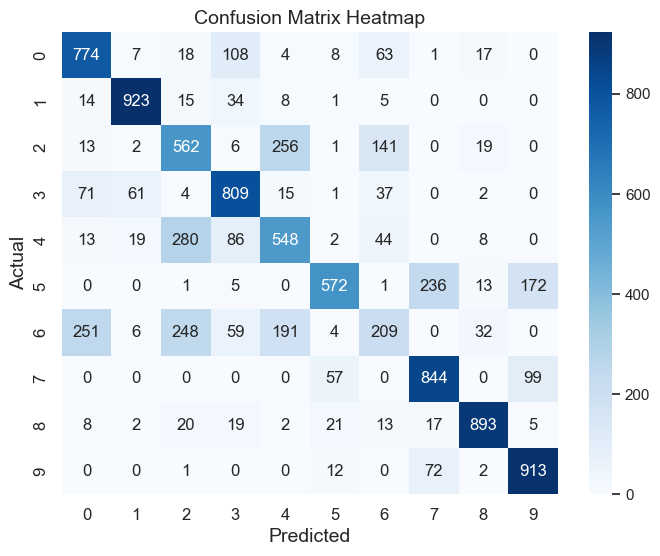

In [101]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [102]:
report = classification_report(y_test, predictions, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.77      0.72      1000
           1       0.90      0.92      0.91      1000
           2       0.49      0.56      0.52      1000
           3       0.72      0.81      0.76      1000
           4       0.54      0.55      0.54      1000
           5       0.84      0.57      0.68      1000
           6       0.41      0.21      0.28      1000
           7       0.72      0.84      0.78      1000
           8       0.91      0.89      0.90      1000
           9       0.77      0.91      0.83      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000

